# Preprocessing Data Buka Tutup Suara

## Import Library

In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import os
import pandas as pd
from IPython.display import Audio, display

## Open Dataset

In [5]:
train = "../dataset/dataset48k/train/"
val = "../dataset/dataset48k/val"

input_base = "data"
output_base = "data_preprocessed"

os.makedirs(output_base, exist_ok=True)

## Fungsi Preprocessing

In [ ]:
def preprocess_audio(input_path, output_path, sr=16000):
    # Load audio
    y, _ = librosa.load(input_path, sr=sr)
    
    # Trim silence
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    # Normalisasi amplitudo
    y_norm = y_trimmed / np.max(np.abs(y_trimmed))
    
    # Simpan
    sf.write(output_path, y_norm, sr)


## Membuat Metadata

In [18]:
rows = []

for split_path, split_name in [(train, "train"), (val, "val")]:
    for label in ["buka", "tutup"]:
        input_folder = os.path.join(split_path, label)
        output_folder = os.path.join(output_base, split_name, label)
        os.makedirs(output_folder, exist_ok=True)
        
        for filename in os.listdir(input_folder):
            if filename.endswith(".wav"):
                in_path = os.path.join(input_folder, filename)
                out_path = os.path.join(output_folder, filename)
                
                try:
                    preprocess_audio(in_path, out_path)
                    rows.append({
                        "split": split_name,
                        "label": label,
                        "file_path": out_path
                    })
                except Exception as e:
                    print(f"Error {filename}: {e}")

metadata = pd.DataFrame(rows)
metadata.to_csv(os.path.join(output_base, "metadata.csv"), index=False)
print("Preprocessing selesai! Metadata disimpan di dataset_preprocessed/metadata.csv")

C:\Users\USERB-PC\AppData\Local\Temp\ipykernel_10468\2553134023.py:9: RuntimeWarning: invalid value encountered in divide
  y_norm = y_trimmed / np.max(np.abs(y_trimmed))


Preprocessing selesai! Metadata disimpan di dataset_preprocessed/metadata.csv


## Preprocessing Data

Durasi sebelum preprocessing : 1.00 detik
Durasi sesudah preprocessing : 0.32 detik



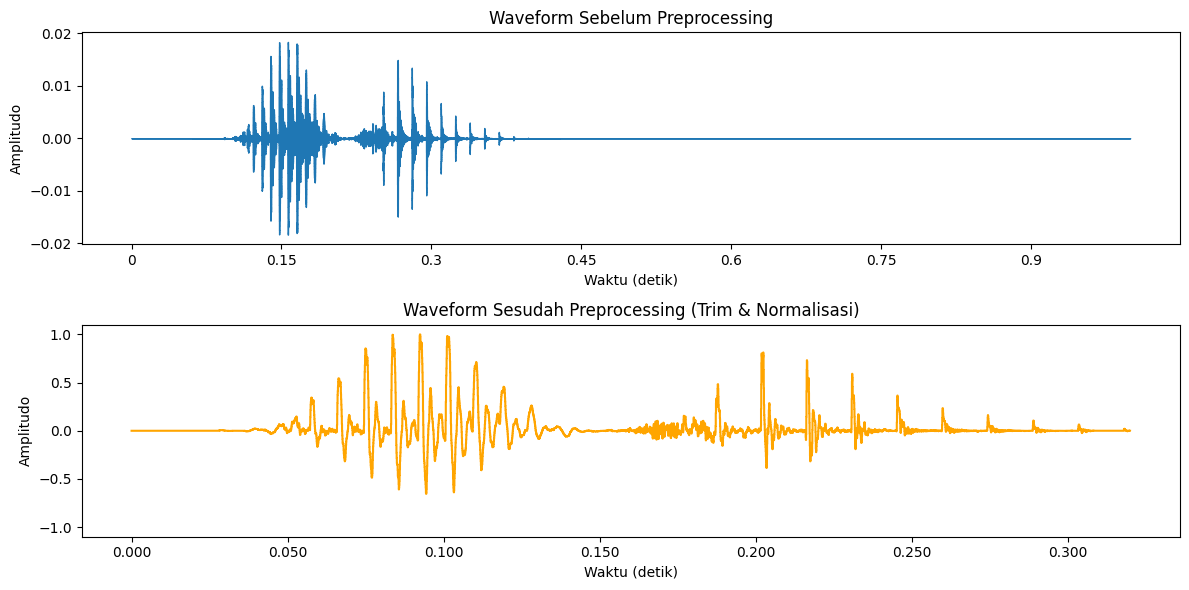

 Sebelum preprocessing:


 Sesudah preprocessing:


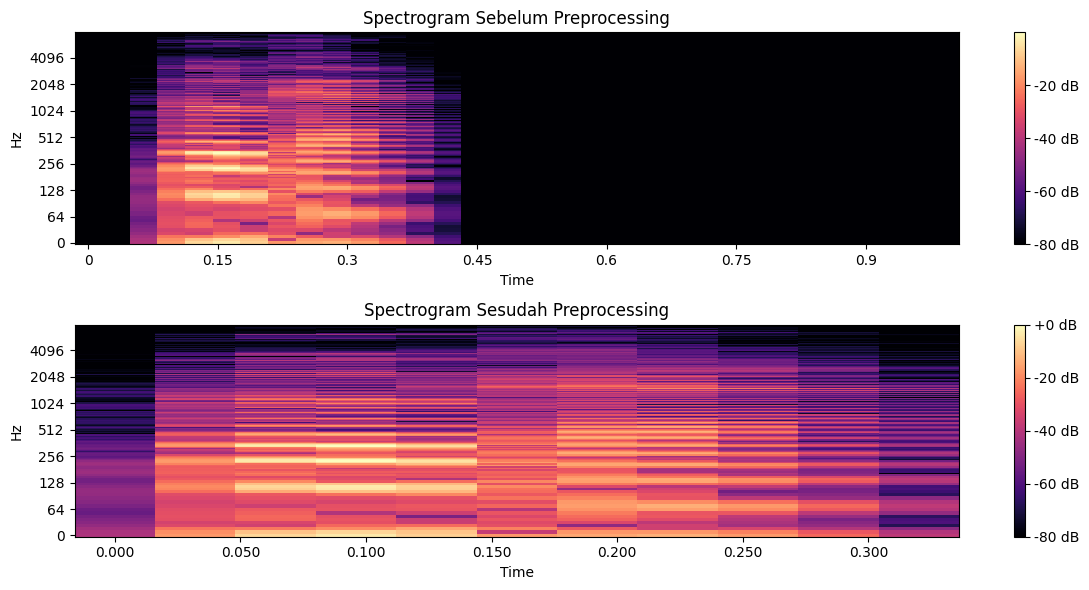

In [25]:
example_file = os.listdir(os.path.join(train, "buka"))[0]

original_file = os.path.join(train, "buka", example_file)
preprocessed_file = os.path.join(output_base, "train", "buka", example_file)

y_orig, sr_orig = librosa.load(original_file, sr=16000)
y_proc, sr_proc = librosa.load(preprocessed_file, sr=16000)

durasi_asli = librosa.get_duration(y=y_orig, sr=sr_orig)
durasi_baru = librosa.get_duration(y=y_proc, sr=sr_proc)

print(f"Durasi sebelum preprocessing : {durasi_asli:.2f} detik")
print(f"Durasi sesudah preprocessing : {durasi_baru:.2f} detik\n")

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(y_orig, sr=sr_orig)
plt.title("Waveform Sebelum Preprocessing")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")

plt.subplot(2, 1, 2)
librosa.display.waveshow(y_proc, sr=sr_proc, color='orange')
plt.title("Waveform Sesudah Preprocessing (Trim & Normalisasi)")
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")

plt.tight_layout()
plt.show()

print(" Sebelum preprocessing:")
display(Audio(data=y_orig, rate=sr_orig))

print(" Sesudah preprocessing:")
display(Audio(data=y_proc, rate=sr_proc))

S_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
S_proc = librosa.amplitude_to_db(np.abs(librosa.stft(y_proc)), ref=np.max)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.specshow(S_orig, sr=sr_orig, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram Sebelum Preprocessing")

plt.subplot(2, 1, 2)
librosa.display.specshow(S_proc, sr=sr_proc, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram Sesudah Preprocessing")

plt.tight_layout()
plt.show()

In [26]:
metadata = pd.read_csv(os.path.join(output_base, "metadata_buka_tutup_suara.csv"))

def extract_features(file_path, label):
    y, sr = librosa.load(file_path, sr=16000)
    
    mean = np.mean(y)
    std = np.std(y)
    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    
    return {
        "file": file_path,
        "label": label,
        "mean": mean,
        "std": std,
        "rms": rms,
        "zcr": zcr,
        "centroid": centroid,
        "bandwidth": bandwidth,
        "contrast": contrast,
        "rolloff": rolloff
    }

features = []
for _, row in metadata.iterrows():
    try:
        feat = extract_features(row['file_path'], row['label'])
        features.append(feat)
    except Exception as e:
        print(f"Error {row['file_path']}: {e}")

features_df = pd.DataFrame(features)
features_df.to_csv(os.path.join(output_base, "features_buka_tutup.csv"), index=False)

print("Done")

Done
